In [16]:
from dotenv import load_dotenv
load_dotenv()

import os

if os.environ['GROQ_API_KEY']:
    print("API Key is Set!!!")
else:
    raise ValueError("API Key not loaded!!!")

API Key is Set!!!


In [17]:
from langchain_groq import ChatGroq
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="llama-3.3-70b-versatile")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.0', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000222B3E30A10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000222B3E6FC20>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

### LLM Schema **(Orchestrator)**

In [18]:
from pydantic import BaseModel, Field
from typing import List,TypedDict

class llm_schema(BaseModel):
    tasks: List[str] = Field(...,description="A list of tasks to be performed by the worker")

In [19]:
llm_with_schema = llm.with_structured_output(llm_schema)

In [20]:
llm_with_schema.invoke("what is the capital of Telangana and who is the director of RRR?")

llm_schema(tasks=['find capital of Telangana', 'find director of RRR movie'])

### Graph Schema

In [21]:
class graph_schema(TypedDict):
    query: str
    tasks: List[str]
    results: List[str]
    summary: str

### **Orchestrator Node**

In [22]:
from langchain_core.prompts import ChatPromptTemplate

def orchestrator_node(state: graph_schema) -> graph_schema:
    input = state['query']

    prompt = ChatPromptTemplate([
        ("system","You are an orchestrator that breaks down user query into tasks for the worker."),
        ("user",f"{input}. Please generate one prompt per task for the worker to complete it.")
    ])

    chain = prompt | llm_with_schema

    response = chain.invoke({"query":input})

    state['tasks'] = response.tasks
    return state

### **Worker Node**

In [30]:
def execute(query: str) :
    response = llm.invoke(f"Please execute this task: {query}").content

    return response

In [24]:
from concurrent.futures import ThreadPoolExecutor

def worker_node(state: graph_schema) -> graph_schema:
    tasks = state['tasks']
    results = state['results']

    with ThreadPoolExecutor(max_workers=len(tasks)) as executor:
        results_future = executor.map(execute, tasks)

        for result in results_future:
            results.append(result)

    state['results'] = results

    return state

### **Collector Node**

In [25]:
from langchain_core.prompts import ChatPromptTemplate

def collector_node(state: graph_schema) -> graph_schema:

    results = state["results"]

    prompt = ChatPromptTemplate([
        (
            "system",
            "You are the collector node for the workflow. "
            "Summarize all the task results into one final answer."
        ),
        (
            "user",
            "Here are the results:\n{results}"
        )
    ])

    chain = prompt | llm

    response = chain.invoke({
        "results": results
    })

    state["summary"] = response.content

    return state

### Creating the graph and executing

In [26]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("orchestrator_node", orchestrator_node)
graph.add_node("worker_node", worker_node)
graph.add_node("collector_node", collector_node)

graph.add_edge(START, "orchestrator_node")
graph.add_edge("orchestrator_node", "worker_node")
graph.add_edge("worker_node", "collector_node")
graph.add_edge("collector_node", END)

orchestrator_worker_graph = graph.compile()

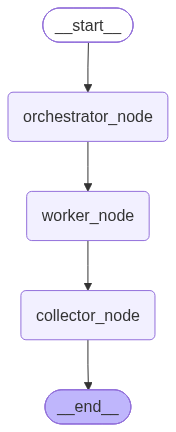

In [27]:
from IPython.display import Image, display

Image(orchestrator_worker_graph.get_graph().draw_mermaid_png())

In [31]:
orchestrator_worker_graph.invoke({
    "query" : "what is the capital of Telangana and who is the director of RRR?",
    "tasks" : "",
    "results" : [],
    "summary" : ""
})

{'query': 'what is the capital of Telangana and who is the director of RRR?',
 'tasks': ['Find the capital of Telangana',
  'Find the director of the movie RRR'],
 'results': ['The capital of Telangana is Hyderabad.',
  'The director of the movie RRR is S.S. Rajamouli.'],
 'summary': 'The final answer is a compilation of the provided results. The capital of Telangana is Hyderabad, and the director of the movie RRR is S.S. Rajamouli.'}

In [32]:
for chunk in orchestrator_worker_graph.invoke({
    "query" : "what is the capital of Telangana and who is the director of RRR?",
    "tasks" : "",
    "results" : [],
    "summary" : ""
}, stream_mode="updates"):
    print(chunk)

{'orchestrator_node': {'query': 'what is the capital of Telangana and who is the director of RRR?', 'tasks': ['Find the capital of Telangana', 'Find the director of the movie RRR'], 'results': ['The capital of Telangana is Hyderabad.', 'The director of the movie "RRR" is S.S. Rajamouli.'], 'summary': ''}}
{'worker_node': {'query': 'what is the capital of Telangana and who is the director of RRR?', 'tasks': ['Find the capital of Telangana', 'Find the director of the movie RRR'], 'results': ['The capital of Telangana is Hyderabad.', 'The director of the movie "RRR" is S.S. Rajamouli.'], 'summary': ''}}
{'collector_node': {'query': 'what is the capital of Telangana and who is the director of RRR?', 'tasks': ['Find the capital of Telangana', 'Find the director of the movie RRR'], 'results': ['The capital of Telangana is Hyderabad.', 'The director of the movie "RRR" is S.S. Rajamouli.'], 'summary': 'The final answer is a compilation of two separate facts: \n\n1. The capital of Telangana is 